<>:54: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
<>:54: SyntaxWarning: invalid escape sequence '\s'
<>:55: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15364\3833613440.py:54: SyntaxWarning: invalid escape sequence '\s'
  ax1.axhline(y=np.sqrt(2), color='red', linestyle='--', alpha=0.6, label='真值 $\sqrt{2}$')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15364\3833613440.py:55: SyntaxWarning: invalid escape sequence '\s'
  ax1.axhline(y=-np.sqrt(2), color='green', linestyle='--', alpha=0.6, label='真值 $-\sqrt{2}$')
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'de

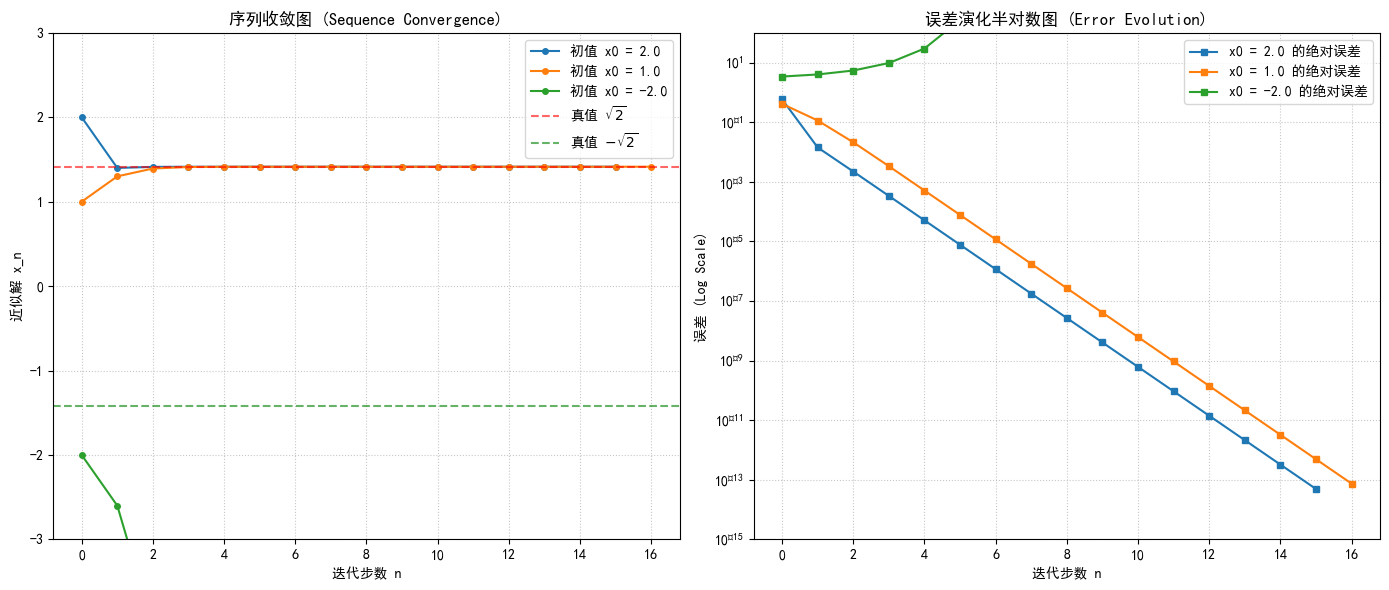

初值 x0      | 最终近似值              | 迭代次数       | 最终状态
----------------------------------------------------------------------
2.0        | 1.414213562373     | 15         | 收敛到正根
   [理论分析] 该初值下误差比率 e_{n+1}/e_n ≈ 0.1515 (符合线性收敛)
1.0        | 1.414213562373     | 16         | 收敛到正根
   [理论分析] 该初值下误差比率 e_{n+1}/e_n ≈ 0.1515 (符合线性收敛)
-2.0       | -144233555.350978493690 | 7          | 发散


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def phi(x):
    """线性不动点迭代格式: phi(x) = x - 0.3 * (x^2 - 2)"""
    return x - 0.3 * (x**2 - 2)

def run_iteration(x0, max_iter=50, tol=1e-12):
    """执行迭代过程并记录数据"""
    true_root = np.sqrt(2)
    x_history = [x0]
    abs_errors = [abs(x0 - true_root)]
    rel_errors = [abs(x0 - true_root) / true_root]
    
    for i in range(max_iter):
        x_prev = x_history[-1]
        x_next = phi(x_prev)
        
        # 记录数据
        x_history.append(x_next)
        abs_err = abs(x_next - true_root)
        abs_errors.append(abs_err)
        rel_errors.append(abs_err / true_root)
        
        # 停止准则：相邻步变化量小于容差
        if abs(x_next - x_prev) < tol:
            break
            
        # 防止发散导致数值溢出（绘图崩溃）
        if abs(x_next) > 1e5: 
            break
            
    return np.array(x_history), np.array(abs_errors), np.array(rel_errors)

# --- 实验开始 ---
initial_values = [2.0, 1.0, -2.0]
results = {}

for x0 in initial_values:
    results[x0] = run_iteration(x0)

# --- 绘图部分 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 图 1: 序列收敛图 (限制了Y轴范围，解决“看起来是0”的问题)
for x0 in initial_values:
    history, _, _ = results[x0]
    ax1.plot(history, 'o-', markersize=4, label=f'初值 x0 = {x0}')

ax1.axhline(y=np.sqrt(2), color='red', linestyle='--', alpha=0.6, label='真值 $\sqrt{2}$')
ax1.axhline(y=-np.sqrt(2), color='green', linestyle='--', alpha=0.6, label='真值 $-\sqrt{2}$')

# 【关键点】限制Y轴范围在 -3 到 3 之间，这样 1.414 就不会被发散项挤没了
ax1.set_ylim(-3, 3) 

ax1.set_title('序列收敛图 (Sequence Convergence)')
ax1.set_xlabel('迭代步数 n')
ax1.set_ylabel('近似解 x_n')
ax1.legend(loc='best')
ax1.grid(True, linestyle=':', alpha=0.7)

# 图 2: 误差随迭代步数变化的半对数图
for x0 in initial_values:
    _, abs_err, _ = results[x0]
    # 使用 semilogy 绘制，收敛时应呈直线下降
    ax2.semilogy(abs_err, 's-', markersize=4, label=f'x0 = {x0} 的绝对误差')

# 限制误差图的显示范围，防止发散数据把刻度拉得太宽
ax2.set_ylim(1e-15, 1e2)

ax2.set_title('误差演化半对数图 (Error Evolution)')
ax2.set_xlabel('迭代步数 n')
ax2.set_ylabel('误差 (Log Scale)')
ax2.legend()
ax2.grid(True, which="both", linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 结果打印与收敛阶分析 ---
print(f"{'初值 x0':<10} | {'最终近似值':<18} | {'迭代次数':<10} | {'最终状态'}")
print("-" * 70)
for x0 in initial_values:
    history, abs_err, rel_err = results[x0]
    final_x = history[-1]
    iters = len(history) - 1
    
    # 判断状态
    if abs(final_x - np.sqrt(2)) < 1e-10:
        status = "收敛到正根"
    elif abs(final_x - (-np.sqrt(2))) < 1e-10:
        status = "收敛到负根"
    else:
        status = "发散"
    
    print(f"{x0:<10.1f} | {final_x:<18.12f} | {iters:<10} | {status}")

    # 对于收敛的情况，计算相邻误差的比值 e_{n+1}/e_n，验证线性收敛
    if status == "收敛到正根" and iters > 5:
        ratio = abs_err[10] / abs_err[9] # 取中间一步观察比率
        print(f"   [理论分析] 该初值下误差比率 e_{{n+1}}/e_n ≈ {ratio:.4f} (符合线性收敛)")